# 01 - Update Models

Retrain MLP classifier for each FaceNet variant + Face Detector combination.
Saves results (images, reports) to `logs/my_logs/`.

In [24]:
import os, pickle, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

TensorFlow: 2.20.0
Keras: 3.12.0


In [25]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
# Fallback: notebook is in notebooks/, project root is parent
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
# Double-check: verify PROJECT_ROOT is correct by looking for a marker
if not os.path.exists(os.path.join(PROJECT_ROOT, 'notebooks')):
    # Maybe CWD is already project root
    PROJECT_ROOT = os.getcwd()

PKL_DIR     = os.path.join(PROJECT_ROOT, 'models', 'precomputed')
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'lfw_funneled')
PAIRS_FILE  = os.path.join(DATASET_DIR, 'pairs.txt')
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'logs', 'my_logs')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PKL_DIR:', PKL_DIR)
print('DATASET_DIR:', DATASET_DIR)
print('PAIRS_FILE:', PAIRS_FILE)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('\nPKL files:', os.listdir(PKL_DIR))

PROJECT_ROOT: x:\sv3_hk2\graduation_thesis\facenet
PKL_DIR: x:\sv3_hk2\graduation_thesis\facenet\models\precomputed
DATASET_DIR: x:\sv3_hk2\graduation_thesis\facenet\data\raw\lfw_funneled
PAIRS_FILE: x:\sv3_hk2\graduation_thesis\facenet\data\raw\lfw_funneled\pairs.txt
OUTPUT_DIR: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs

PKL files: ['Facenet512_mtcnn_embeddings.pkl', 'Facenet512_retinaface_embeddings.pkl', 'Facenet_mtcnn_embeddings.pkl', 'Facenet_retinaface_embeddings.pkl', 'my_logs-20260426T091235Z-3-001.zip']


In [26]:
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    sm=sum(l==1 for _,_,l in pairs)
    print(f'{len(pairs)} pairs (same={sm}, diff={len(pairs)-sm})')
    return pairs

In [27]:
def load_pkl_remap(pkl_path, new_base):
    """Load PKL and remap Colab paths to local paths."""
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.normpath(os.path.join(new_base, rel))
        else:
            new_key = k
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} embeddings from {os.path.basename(pkl_path)}')
    return remapped

In [28]:
def build_features(pairs, emb_dict):
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.abs(e1-e2)); y.append(lbl)
    return np.array(X), np.array(y)

In [29]:
def build_mlp(dim):
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu'), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [30]:
def compute_eer(yt, ys):
    ths=np.linspace(0,1,500); fl,rl=[],[]
    for t in ths:
        yp=(ys>=t).astype(int)
        fp=np.sum((yp==1)&(yt==0)); tn=np.sum((yp==0)&(yt==0))
        fn=np.sum((yp==0)&(yt==1)); tp=np.sum((yp==1)&(yt==1))
        fl.append(fp/(fp+tn+1e-9)); rl.append(fn/(fn+tp+1e-9))
    far,frr=np.array(fl),np.array(rl)
    idx=np.argmin(np.abs(far-frr))
    return (far[idx]+frr[idx])/2, ths[idx], ths, far, frr

In [31]:
def visualize_mlp_results(hist, ths, far, frr, eer, eer_t, tag, output_path):

    epochs = range(1, len(hist.history['accuracy']) + 1)

    # 1. Accuracy
    plt.figure(figsize=(12, 7))
    train_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy', linewidth=2, markersize=7)
    plt.plot(epochs, val_acc, 'rs-', label='Validation Accuracy', linewidth=2, markersize=7)
    for i in range(len(epochs)):
        plt.annotate(f'{train_acc[i]:.2f}', (epochs[i], train_acc[i]),
                     textcoords="offset points", xytext=(0, 10), ha='center', color='blue', fontsize=8, fontweight='bold')
        plt.annotate(f'{val_acc[i]:.2f}', (epochs[i], val_acc[i]),
                     textcoords="offset points", xytext=(0, -15), ha='center', color='red', fontsize=8, fontweight='bold')
    plt.title(f'{tag} — Accuracy per Epoch', fontsize=15, pad=20)
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.ylim(min(val_acc) - 0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'accuracy.png'), dpi=150)
    plt.show()
    plt.close()

    # 2. Loss
    plt.figure(figsize=(12, 7))
    train_loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    plt.plot(epochs, train_loss, 'go-', label='Training Loss', linewidth=2, markersize=7)
    plt.plot(epochs, val_loss, 'mo-', label='Validation Loss', linewidth=2, markersize=7)
    for i in range(len(epochs)):
        plt.annotate(f'{train_loss[i]:.2f}', (epochs[i], train_loss[i]),
                     textcoords="offset points", xytext=(0, -15), ha='center', color='green', fontsize=8, fontweight='bold')
        plt.annotate(f'{val_loss[i]:.2f}', (epochs[i], val_loss[i]),
                     textcoords="offset points", xytext=(0, 10), ha='center', color='purple', fontsize=8, fontweight='bold')
    plt.title(f'{tag} — Loss per Epoch', fontsize=15, pad=20)
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.ylim(0, max(val_loss) + 0.2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'loss.png'), dpi=150)
    plt.show()
    plt.close()

    # 3. FAR / FRR
    plt.figure(figsize=(8,5))
    plt.plot(ths, far, label='FAR', color='steelblue')
    plt.plot(ths, frr, label='FRR', color='orange')
    plt.axvline(x=eer_t, color='red', linestyle='--', label=f'EER:{eer:.4f}')
    plt.title(f'{tag} — FAR vs FRR')
    plt.xlabel('Threshold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'far_frr.png'), dpi=150)
    plt.show()
    plt.close()

In [32]:
def plot_confusion_matrix(y_true, y_pred, classes, output_path, normalize=True):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix', fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center",
                     color="white" if value > cm.max()/2 else "black",
                     fontsize=10, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{output_path}/confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

In [33]:
def save_mlp_report(model_name, detector, tra, tea, trl, tel, prec, rec, f1v, eer, eer_t, far_at_eer, frr_at_eer, infer_avg_s, output_path):
    rpt=(
        "--- BAO CAO KET QUA NHAN DIEN ---\n"
        f"Model: {model_name} | Detector: {detector}\n"
        f"EER dat duoc: {eer:.4f} tai Threshold: {eer_t:.4f}\n"
        f"Train Accuracy: {tra:.4f}\nTest Accuracy:  {tea:.4f}\n"
        f"Train Loss: {trl:.4f}\nTest Loss:  {tel:.4f}\n"
        f"Precision: {prec:.4f}\nRecall: {rec:.4f}\nF1-Score: {f1v:.4f}\n"
        f"FAR tai EER: {far_at_eer:.4f}\nFRR tai EER: {frr_at_eer:.4f}\n"
        f"TB predict/anh: {infer_avg_s:.4f}s\n"
    )
    print(rpt)
    with open(os.path.join(output_path,'final_report.txt'),'w',encoding='utf-8') as f: f.write(rpt)

In [34]:
def run_mlp_model_logic(pairs, pkl_path, dataset_dir, epochs=16):
    emb_dict = load_pkl_remap(pkl_path, dataset_dir)
    X, y = build_features(pairs, emb_dict)
    print(f'Features: {X.shape}')
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    mlp = build_mlp(Xtr.shape[1])
    cb  = keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
    hist = mlp.fit(Xtr,ytr,epochs=epochs,batch_size=64,
                   validation_split=0.15,callbacks=[cb],verbose=1)
    t0=time.time(); ys=mlp.predict(Xte,verbose=0).flatten(); tit=time.time()-t0
    yp=(ys>=0.5).astype(int)
    trl,tra=mlp.evaluate(Xtr,ytr,verbose=0)
    tel,tea=mlp.evaluate(Xte,yte,verbose=0)
    prec=precision_score(yte,yp,zero_division=0)
    rec=recall_score(yte,yp,zero_division=0)
    f1v=f1_score(yte,yp,zero_division=0)
    eer,eer_t,ths,far,frr=compute_eer(yte,ys)
    infer_avg_s = tit / len(Xte)
    return (
        hist, yte, ys,
        tra, tea, trl, tel,
        prec, rec, f1v,
        eer, eer_t, ths, far, frr,
        infer_avg_s, yte, yp
    )

In [35]:
def run_mlp_from_pkl(pairs, pkl_path, model_name, detector, output_dir, epochs=16):
    tag = f'{model_name}_{detector}'
    od  = os.path.join(output_dir, tag)
    os.makedirs(od, exist_ok=True)
    print(f'\n{"="*55}\n RUNNING: {tag}\n{"="*55}')

    hist, yte_raw, ys_raw, \
    tra, tea, trl, tel, \
    prec, rec, f1v, \
    eer, eer_t, ths, far, frr, \
    infer_avg_s, y_true, y_pred = run_mlp_model_logic(pairs, pkl_path, DATASET_DIR, epochs=epochs)

    ei=np.argmin(np.abs(ths-eer_t))
    far_at_eer = far[ei]
    frr_at_eer = frr[ei]

    visualize_mlp_results(hist, ths, far, frr, eer, eer_t, tag, od)
    plot_confusion_matrix(y_true, y_pred, classes=['different', 'same'], output_path=od)

    report = classification_report(y_true, y_pred, target_names=['different', 'same'], zero_division=0)
    print('\n--- CLASSIFICATION REPORT ---\n')
    print(report)
    with open(os.path.join(od, 'classification_report.txt'), 'w', encoding='utf-8') as f: f.write(report)

    save_mlp_report(model_name, detector, tra, tea, trl, tel, prec, rec, f1v, eer, eer_t, far_at_eer, frr_at_eer, infer_avg_s, od)

    return {'model':tag,'train_acc':round(tra,4),'test_acc':round(tea,4),
            'precision':round(prec,4),'recall':round(rec,4),'f1':round(f1v,4),
            'eer':round(eer,4),'threshold':round(float(eer_t),4),
            'train_loss':round(trl,4),'test_loss':round(tel,4),
            'infer_avg_s':round(infer_avg_s,6)}

## Load pairs

In [36]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
all_results = []
print('Ready!')

5996 pairs (same=2998, diff=2998)
Ready!


## Model 1: Facenet + MTCNN


 RUNNING: Facenet_mtcnn
Loaded 7701 embeddings from Facenet_mtcnn_embeddings.pkl
Features: (5996, 128)
Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8788 - loss: 0.2933 - val_accuracy: 0.4972 - val_loss: 2.6054
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9225 - loss: 0.2018 - val_accuracy: 0.6528 - val_loss: 1.1397
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9284 - loss: 0.1836 - val_accuracy: 0.8264 - val_loss: 0.4562
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9347 - loss: 0.1736 - val_accuracy: 0.8667 - val_loss: 0.3382
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9350 - loss: 0.1592 - val_accuracy: 0.9028 - val_loss: 0.2823
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9352 - loss: 0.1665 - val_accuracy: 0.9167 - val_loss: 0.2589
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9367 - loss: 0.1565 - val_accuracy: 0.9167 - val_loss: 0.2425
Epoch 8/16
64/

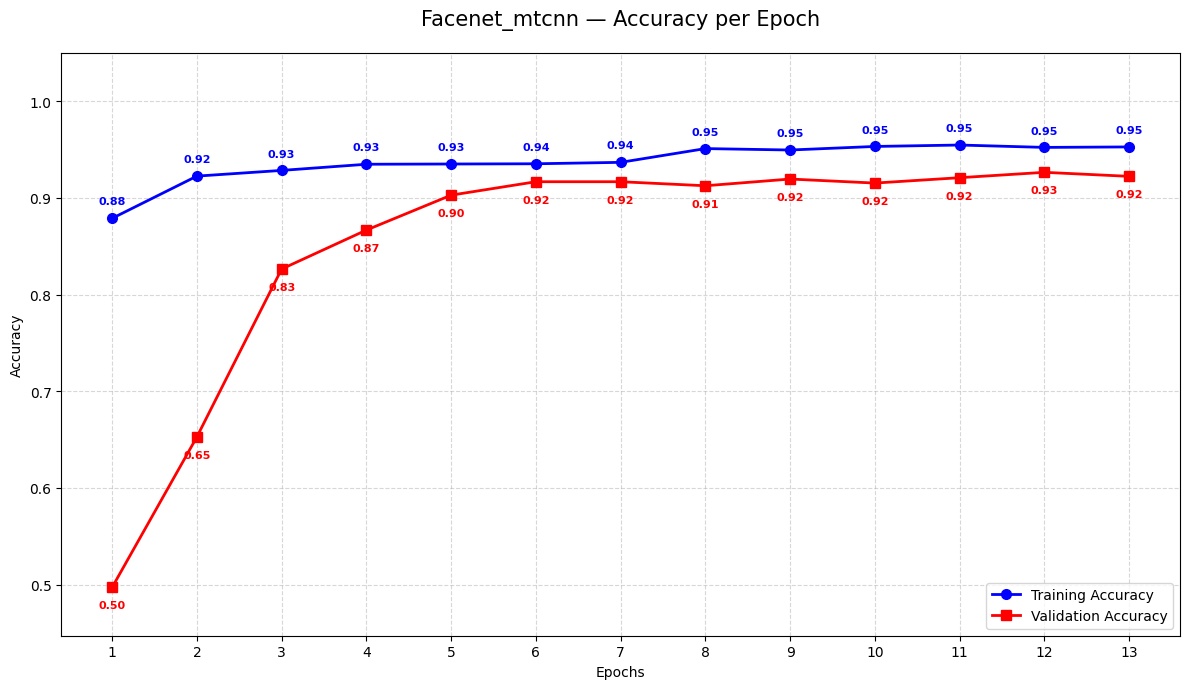

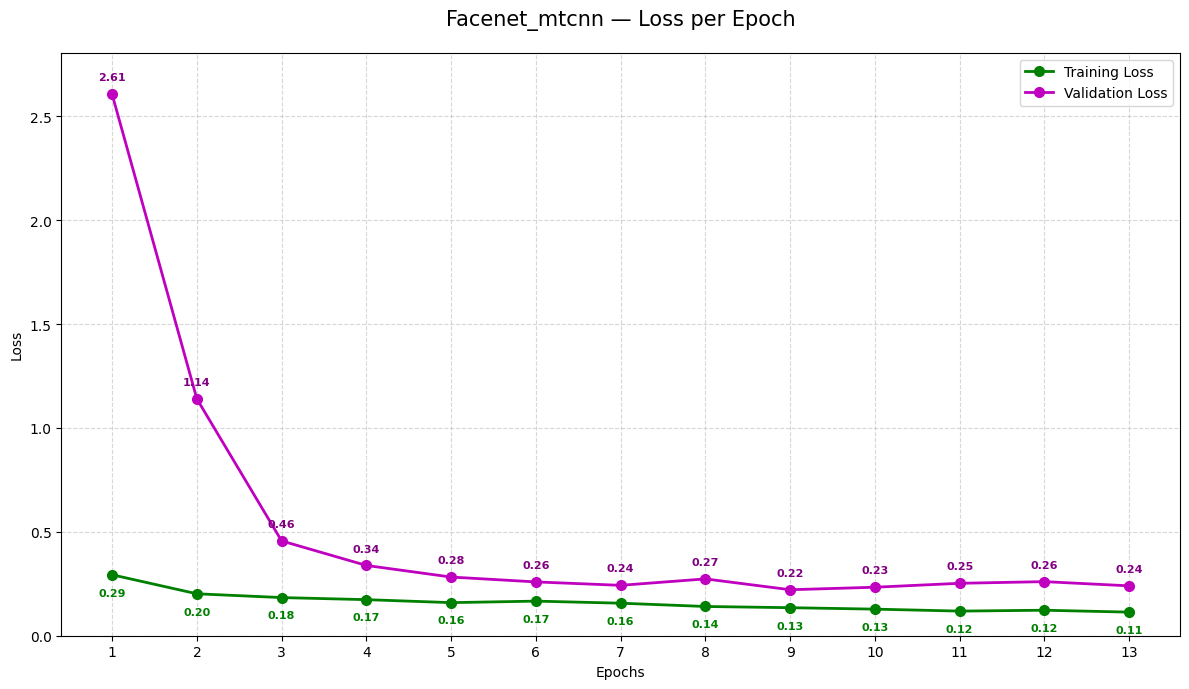

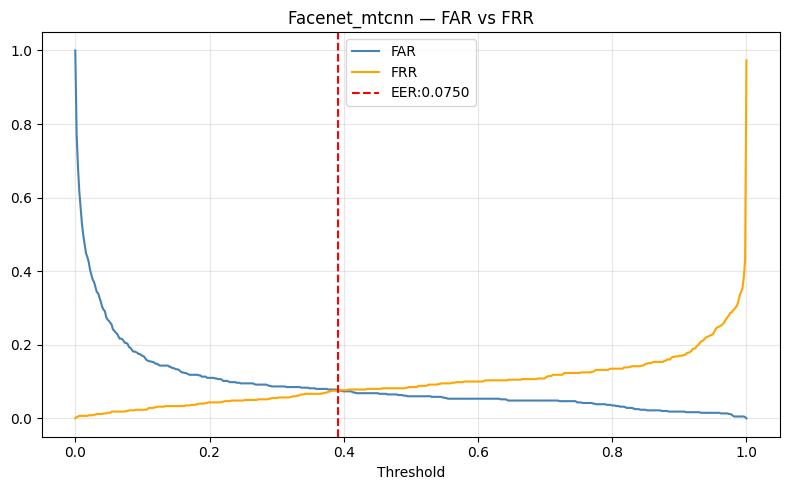

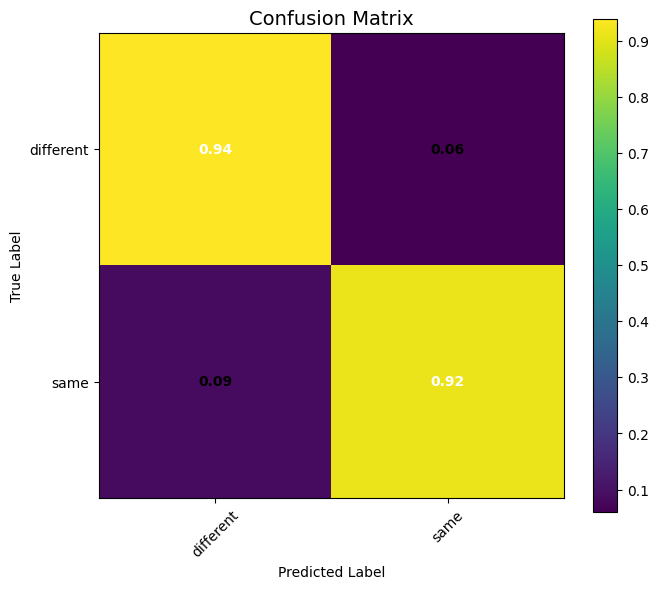


--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

   different       0.92      0.94      0.93       600
        same       0.94      0.92      0.93       600

    accuracy                           0.93      1200
   macro avg       0.93      0.93      0.93      1200
weighted avg       0.93      0.93      0.93      1200

--- BAO CAO KET QUA NHAN DIEN ---
Model: Facenet | Detector: mtcnn
EER dat duoc: 0.0750 tai Threshold: 0.3908
Train Accuracy: 0.9623
Test Accuracy:  0.9275
Train Loss: 0.1104
Test Loss:  0.1976
Precision: 0.9385
Recall: 0.9150
F1-Score: 0.9266
FAR tai EER: 0.0750
FRR tai EER: 0.0750
TB predict/anh: 0.0002s

Model 1 done!


In [37]:
pkl1 = os.path.join(PKL_DIR, 'Facenet_mtcnn_embeddings.pkl')
r1 = run_mlp_from_pkl(pairs, pkl1, 'Facenet', 'mtcnn', OUTPUT_DIR)
all_results.append(r1)
print('Model 1 done!')

## Model 2: Facenet + RetinaFace


 RUNNING: Facenet_retinaface
Loaded 7701 embeddings from Facenet_retinaface_embeddings.pkl
Features: (5996, 128)
Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9046 - loss: 0.2384 - val_accuracy: 0.5000 - val_loss: 2.9024
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9463 - loss: 0.1538 - val_accuracy: 0.6736 - val_loss: 1.0916
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9539 - loss: 0.1252 - val_accuracy: 0.8417 - val_loss: 0.5390
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9531 - loss: 0.1280 - val_accuracy: 0.8917 - val_loss: 0.3525
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9519 - loss: 0.1275 - val_accuracy: 0.9264 - val_loss: 0.2511
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.1143 - val_accuracy: 0.9319 - val_loss: 0.2363
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9605 - loss: 0.1063 - val_accuracy: 0.9347 - val_loss: 0.2203
Epoc

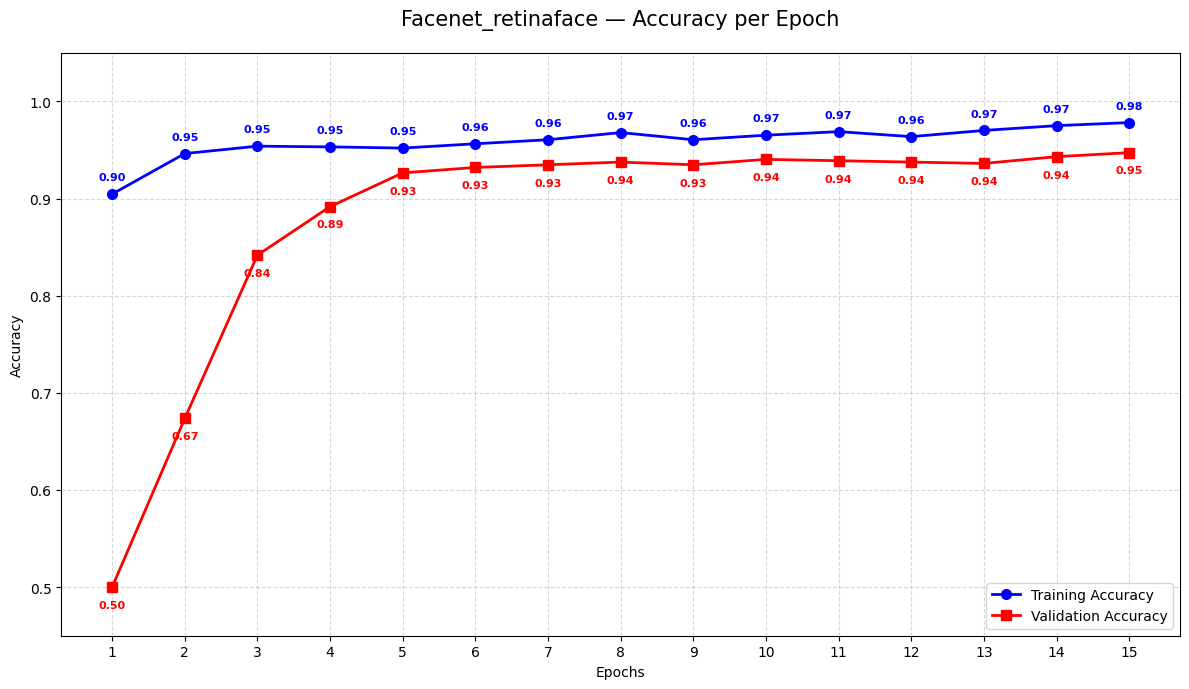

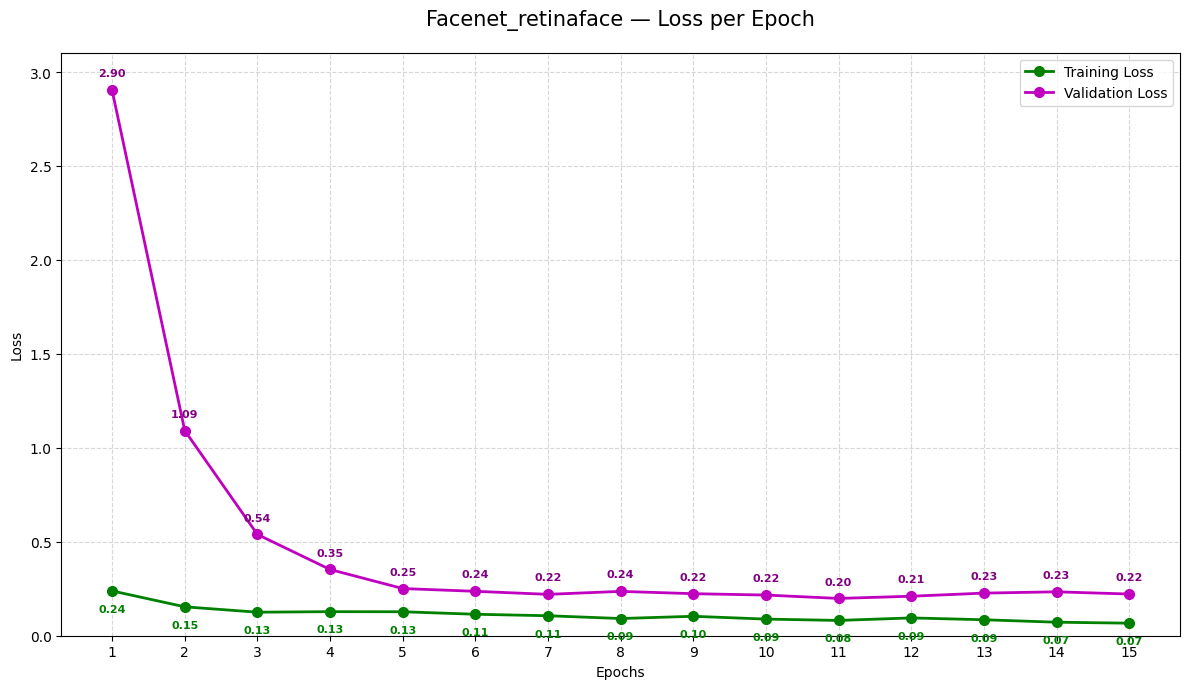

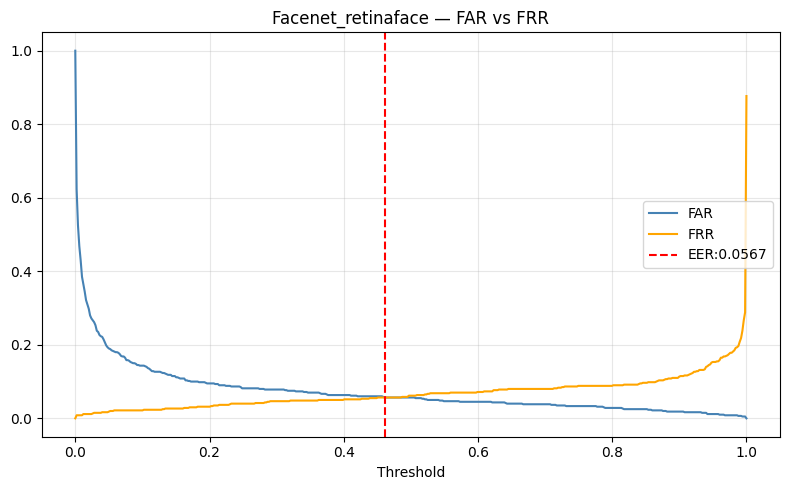

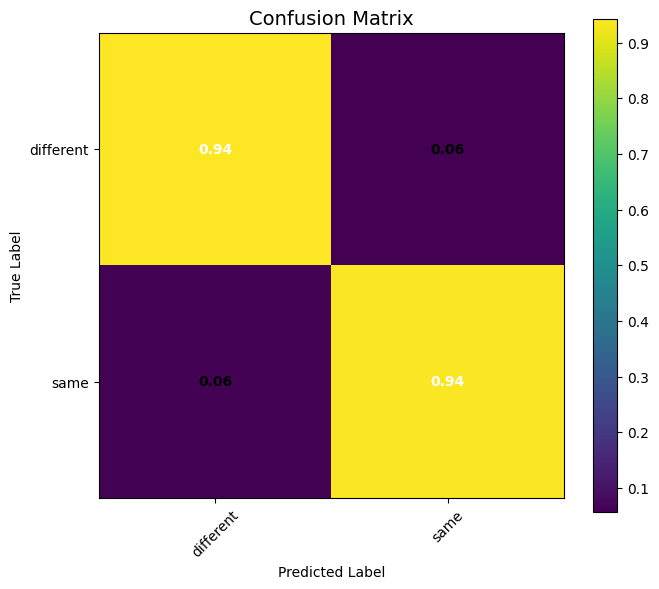


--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

   different       0.94      0.94      0.94       600
        same       0.94      0.94      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200

--- BAO CAO KET QUA NHAN DIEN ---
Model: Facenet | Detector: retinaface
EER dat duoc: 0.0567 tai Threshold: 0.4609
Train Accuracy: 0.9775
Test Accuracy:  0.9408
Train Loss: 0.0750
Test Loss:  0.1758
Precision: 0.9430
Recall: 0.9383
F1-Score: 0.9407
FAR tai EER: 0.0567
FRR tai EER: 0.0567
TB predict/anh: 0.0002s

Model 2 done!


In [38]:
pkl2 = os.path.join(PKL_DIR, 'Facenet_retinaface_embeddings.pkl')
r2 = run_mlp_from_pkl(pairs, pkl2, 'Facenet', 'retinaface', OUTPUT_DIR)
all_results.append(r2)
print('Model 2 done!')

## Model 3: Facenet512 + MTCNN


 RUNNING: Facenet512_mtcnn
Loaded 7701 embeddings from Facenet512_mtcnn_embeddings.pkl
Features: (5996, 512)
Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9033 - loss: 0.2567 - val_accuracy: 0.4972 - val_loss: 2.8136
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9419 - loss: 0.1740 - val_accuracy: 0.7250 - val_loss: 0.6681
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9492 - loss: 0.1506 - val_accuracy: 0.8292 - val_loss: 0.6201
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.1361 - val_accuracy: 0.9056 - val_loss: 0.2855
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1143 - val_accuracy: 0.9306 - val_loss: 0.2131
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9583 - loss: 0.1175 - val_accuracy: 0.9292 - val_loss: 0.2038
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9632 - loss: 0.1056 - val_accuracy: 0.9250 - val_loss: 0.2720
Epoch 8

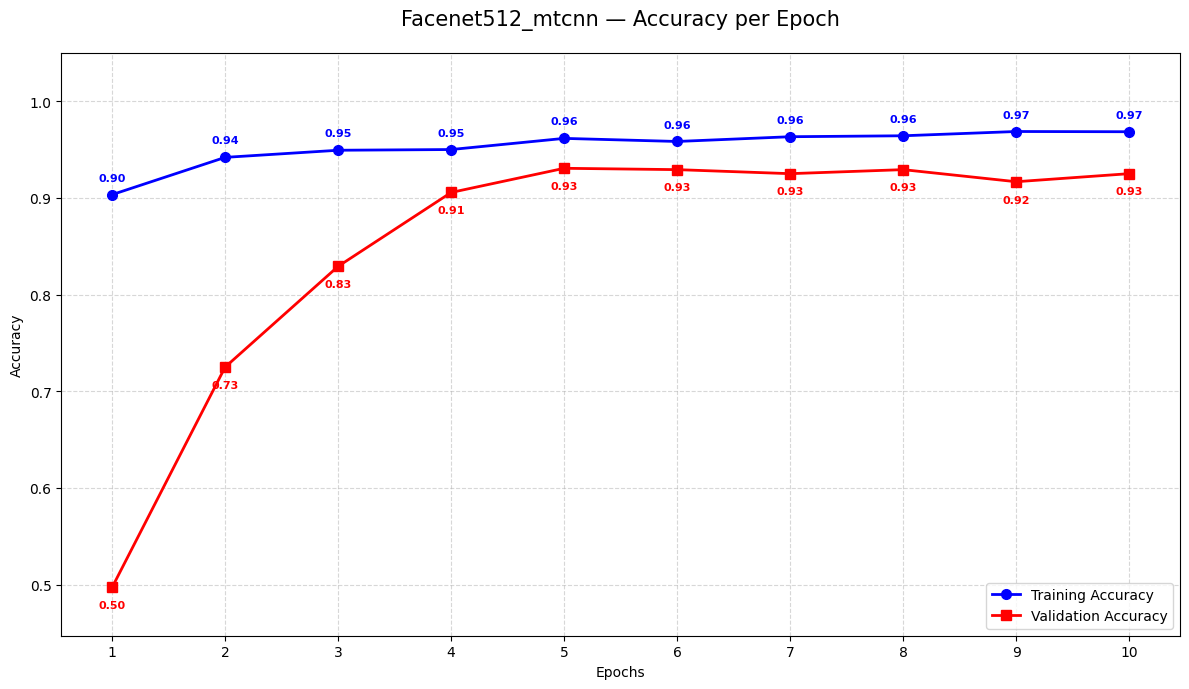

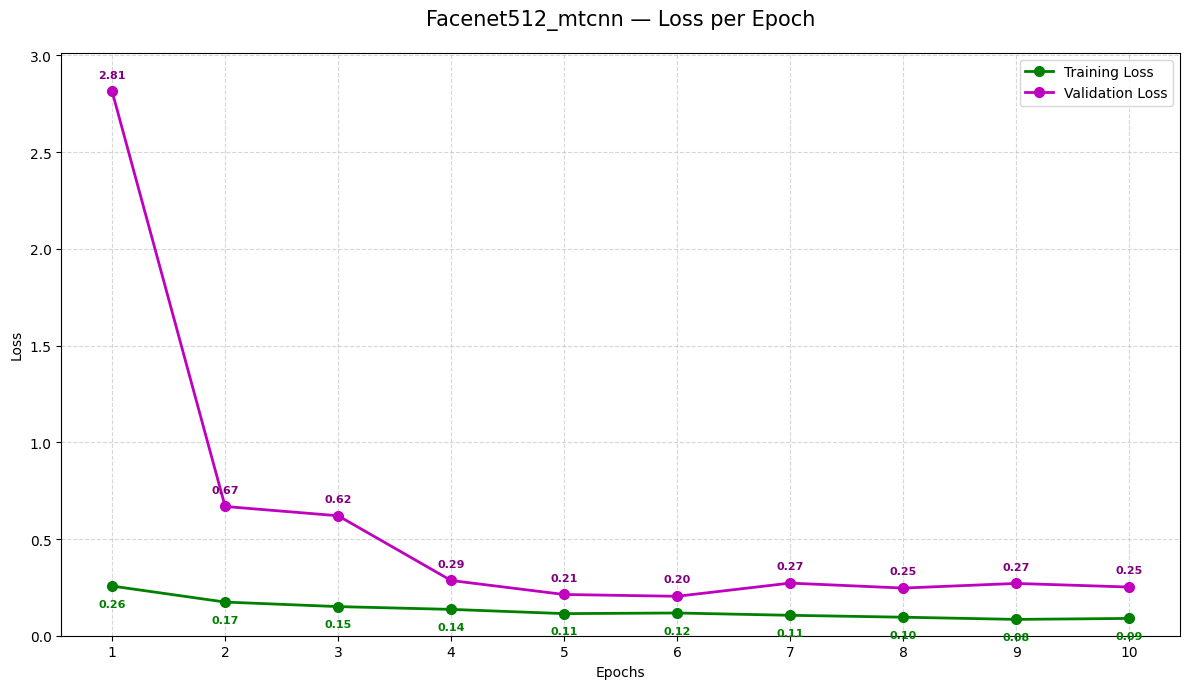

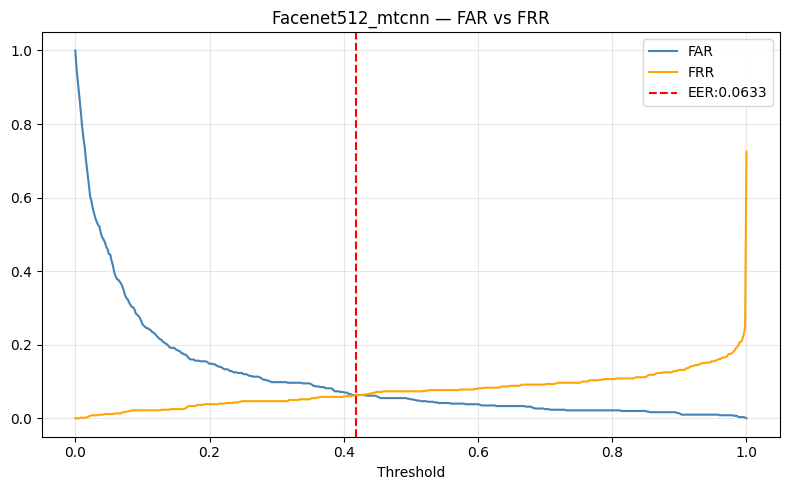

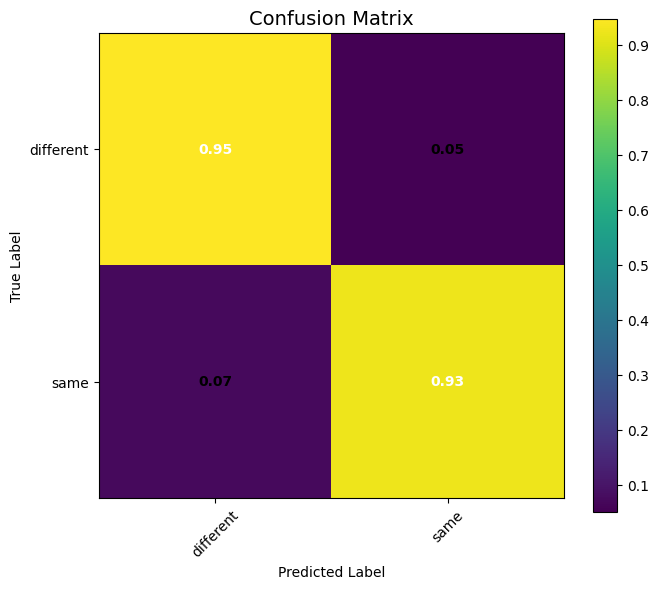


--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

   different       0.93      0.95      0.94       600
        same       0.95      0.93      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200

--- BAO CAO KET QUA NHAN DIEN ---
Model: Facenet512 | Detector: mtcnn
EER dat duoc: 0.0633 tai Threshold: 0.4188
Train Accuracy: 0.9710
Test Accuracy:  0.9375
Train Loss: 0.0952
Test Loss:  0.1752
Precision: 0.9472
Recall: 0.9267
F1-Score: 0.9368
FAR tai EER: 0.0633
FRR tai EER: 0.0633
TB predict/anh: 0.0002s

Model 3 done!


In [39]:
pkl3 = os.path.join(PKL_DIR, 'Facenet512_mtcnn_embeddings.pkl')
r3 = run_mlp_from_pkl(pairs, pkl3, 'Facenet512', 'mtcnn', OUTPUT_DIR)
all_results.append(r3)
print('Model 3 done!')

## Model 4: Facenet512 + RetinaFace


 RUNNING: Facenet512_retinaface
Loaded 7701 embeddings from Facenet512_retinaface_embeddings.pkl
Features: (5996, 512)
Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9271 - loss: 0.1919 - val_accuracy: 0.4944 - val_loss: 3.7227
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9580 - loss: 0.1207 - val_accuracy: 0.7667 - val_loss: 0.7146
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9637 - loss: 0.1009 - val_accuracy: 0.8833 - val_loss: 0.4493
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9666 - loss: 0.0916 - val_accuracy: 0.9417 - val_loss: 0.1830
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9708 - loss: 0.0804 - val_accuracy: 0.9403 - val_loss: 0.2035
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9747 - loss: 0.0712 - val_accuracy: 0.9472 - val_loss: 0.1989
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9767 - loss: 0.0597 - val_accuracy: 0.9500 - val_loss: 0.229

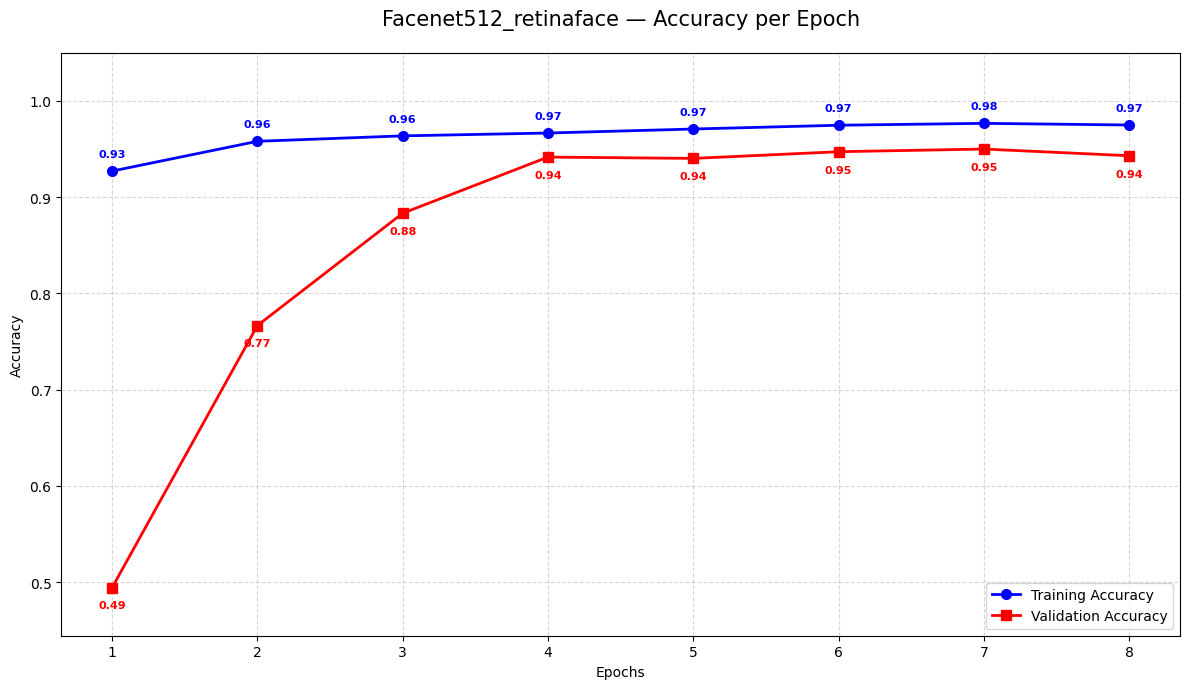

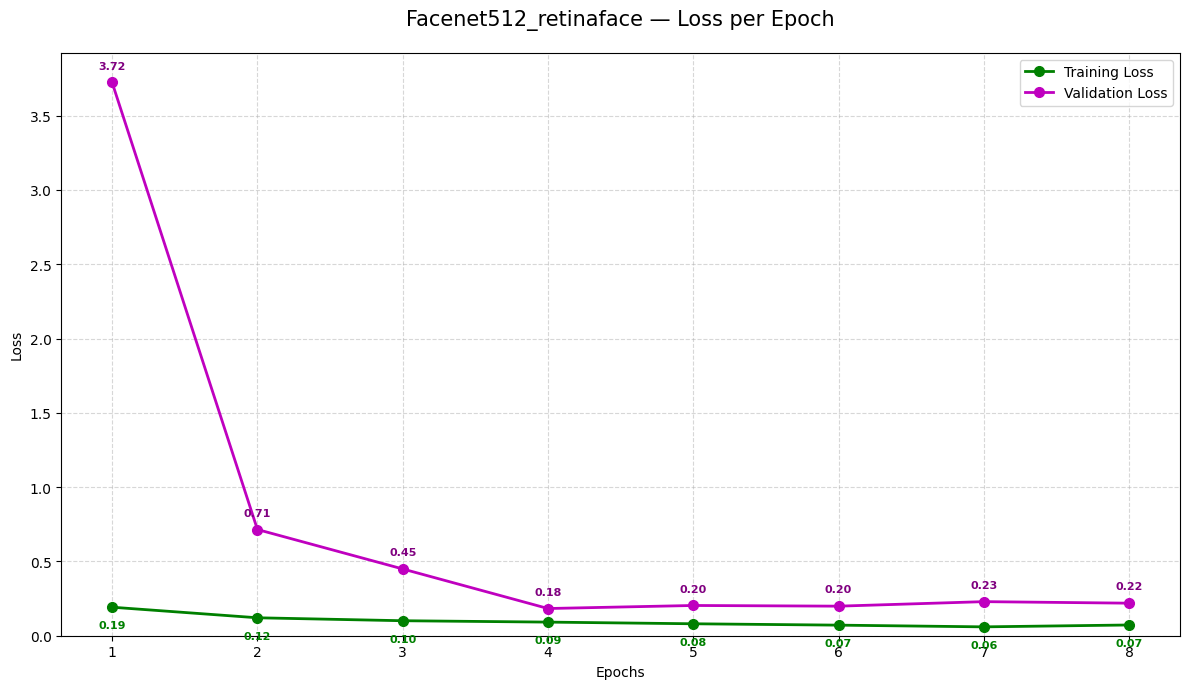

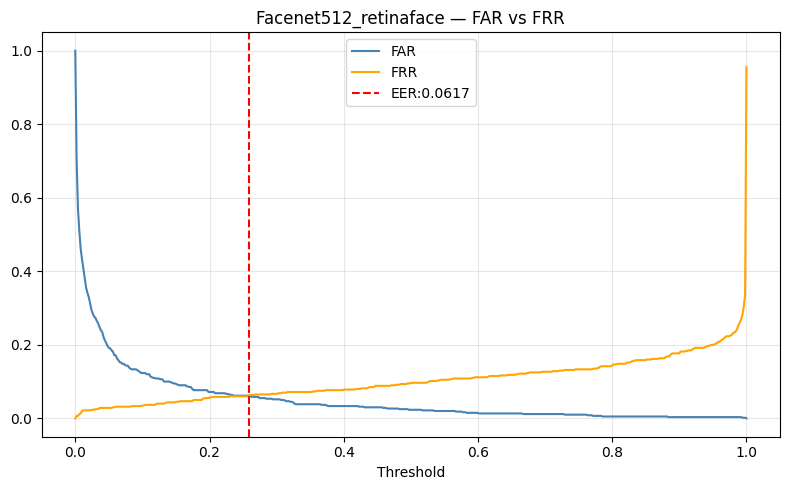

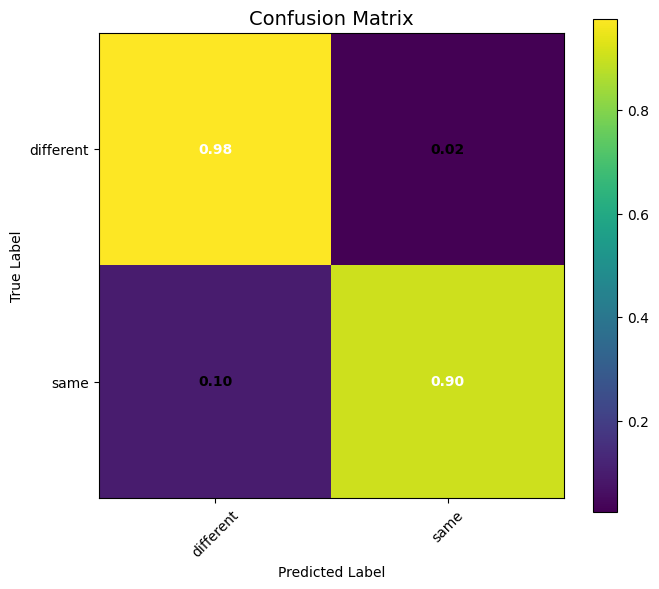


--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

   different       0.91      0.98      0.94       600
        same       0.97      0.90      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200

--- BAO CAO KET QUA NHAN DIEN ---
Model: Facenet512 | Detector: retinaface
EER dat duoc: 0.0617 tai Threshold: 0.2585
Train Accuracy: 0.9721
Test Accuracy:  0.9400
Train Loss: 0.0820
Test Loss:  0.1811
Precision: 0.9748
Recall: 0.9033
F1-Score: 0.9377
FAR tai EER: 0.0617
FRR tai EER: 0.0617
TB predict/anh: 0.0002s

Model 4 done!


In [40]:
pkl4 = os.path.join(PKL_DIR, 'Facenet512_retinaface_embeddings.pkl')
r4 = run_mlp_from_pkl(pairs, pkl4, 'Facenet512', 'retinaface', OUTPUT_DIR)
all_results.append(r4)
print('Model 4 done!')

## Summary & Comparison

In [41]:
df = pd.DataFrame(all_results)
print('\n========== COMPARISON SUMMARY ==========')
print(df.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, 'MLP_Model_Evaluation_Metrics.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved metrics to: {csv_path}')


========== COMPARISON SUMMARY ==========
                model  train_acc  test_acc  precision  recall     f1    eer  threshold  train_loss  test_loss  infer_avg_s
        Facenet_mtcnn     0.9623    0.9275     0.9385  0.9150 0.9266 0.0750     0.3908      0.1104     0.1976     0.000194
   Facenet_retinaface     0.9775    0.9408     0.9430  0.9383 0.9407 0.0567     0.4609      0.0750     0.1758     0.000176
     Facenet512_mtcnn     0.9710    0.9375     0.9472  0.9267 0.9368 0.0633     0.4188      0.0952     0.1752     0.000183
Facenet512_retinaface     0.9721    0.9400     0.9748  0.9033 0.9377 0.0617     0.2585      0.0820     0.1811     0.000186

Saved metrics to: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs\MLP_Model_Evaluation_Metrics.csv


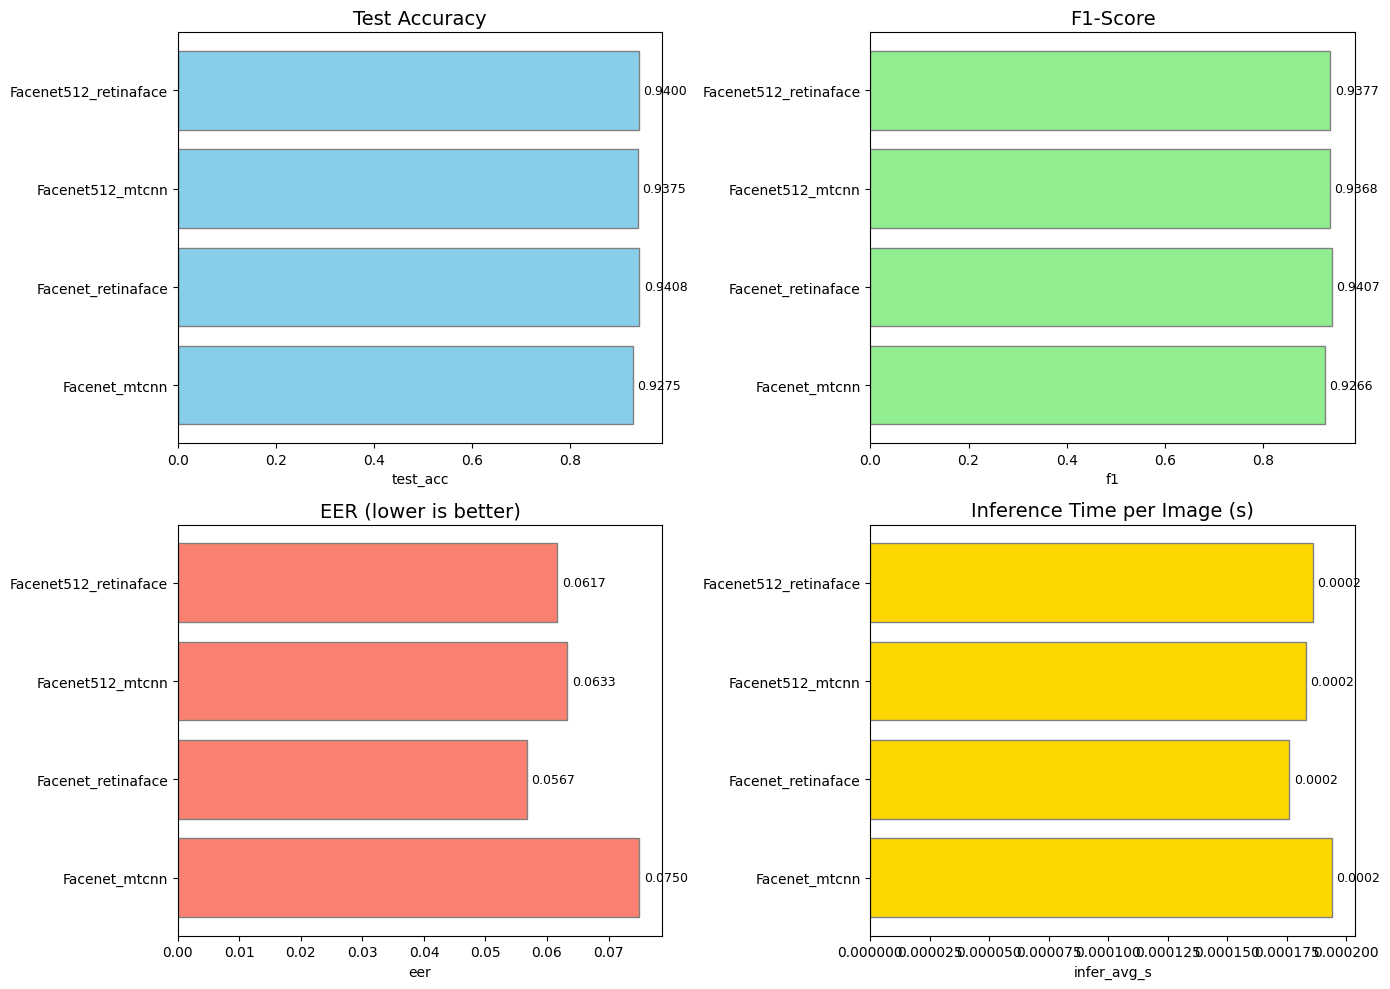

Comparison chart saved!


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['test_acc', 'f1', 'eer', 'infer_avg_s']
titles = ['Test Accuracy', 'F1-Score', 'EER (lower is better)', 'Inference Time per Image (s)']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
    vals = df[metric]
    bars = ax.barh(df['model'], vals, color=color, edgecolor='gray')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_4models.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Comparison chart saved!')

In [43]:
print(f"All results saved to: {OUTPUT_DIR}")
print('Done!')

All results saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs
Done!
